# Model - multi-components & uncertainty

This example shows how to use `lmfit_global.LmfitGlobal` class to fit data with multi-components and evaluate uncertainty. 

This example is similar to `model_uncertainty2.py` of [lmfit examples](https://lmfit.github.io/lmfit-py/examples/index.html) or [github link](https://github.com/lmfit/lmfit-py/tree/master/examples)


In [1]:
try:
    from lmfit_global import LmfitGlobal
    from lmfit_global.utils import lineshapes
    from lmfit_global.utils.builders import GlobalFitBuilder
except (ImportError, ModuleNotFoundError):
    import os, sys
    ROOT = os.path.abspath("..")  # parent of examples
    sys.path.insert(0, ROOT)

    from lmfit_global import LmfitGlobal
    from lmfit_global.utils import lineshapes
    from lmfit_global.utils.builders import GlobalFitBuilder

import matplotlib
import matplotlib.pyplot as plt

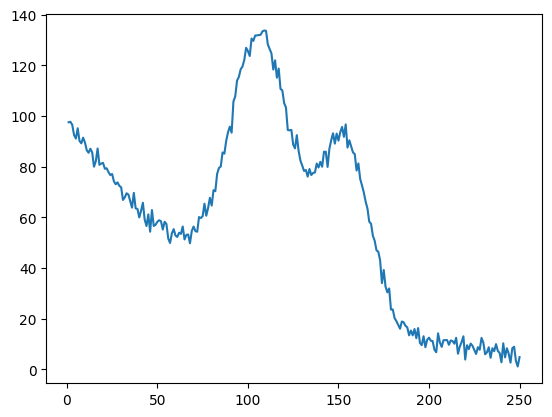

In [2]:
import os
import numpy as np
dpath = './data'  # data path

# --- Load data (skip header) ---
file = 'NIST_Gauss2.dat' # data
file = os.path.join(
    dpath,
    file
)

data = np.loadtxt(file)
x = data[:, 1]  # second  columm as x
y = data[:, 0]  # first   column as y

xy = np.column_stack([x, y])

plt.plot(x, y)
plt.show()

In [3]:
init_expone = {
        'amplitude': {'value':100, 'vary':True, 'min':-np.inf, 'max':+np.inf},
        'decay': {'value':80, },
}

init_gauss1 = {
    'amplitude': {'value':3000, 'vary':True, 'min':-np.inf, 'max':+np.inf},
    'center': {'value':100, },
    'sigma': {'value':10, },
}

init_gauss2 = {
    'amplitude': {'value':3000, 'vary':True, 'min':-np.inf, 'max':+np.inf},
    'center': {'value':150, },
    'sigma': {'value':10, },
}


In [4]:
builder = (
    GlobalFitBuilder()
    .set_data(x, y)                      # x and all y datasets
    .add_model(lineshapes.exponential,   init_expone, func_kws={})
    .add_model(lineshapes.gaussian,      init_gauss1, func_kws={})      
    .add_model(lineshapes.gaussian,      init_gauss2, func_kws={})     
    .connect("+", "+")                             # how to combine the 2 functions
)

items = builder.build()

In [5]:
lg = LmfitGlobal(items)
lg.fit(iter_cb=None)

INFO: Parsing inputs...
INFO: Parsing input data...
INFO: Detected 1 dataset(s) with N=250 points each...
INFO: XRANGE: N=250 points each for user supplied xrange [1.0, 250.0] ...
INFO: Parsing input data COMPLETED...
INFO: Parsing function models...
INFO: 3 model component(s) detected — multi-component fit...
INFO: The model connectors used: [+ +]
INFO: Parsing function models COMPLETED...
INFO: The model is to be constructed as...
INFO: #############################################################################
INFO: # y(x;) = exponential(x, amplitude, decay) + gaussian(x, amplitude, center, #
INFO: # sigma) + gaussian(x, amplitude, center, sigma)                            #
INFO: #############################################################################
INFO: Building lmfit backend...
INFO: Creating lmfit.Models for the models(s) function(s)...
INFO: Building lmfit CompositeModel...
INFO: CompositeModel built successfully...
INFO: Initialized parameters...
INFO: Fitting starte

[[Model]]
    ((Model(exponential, prefix='c0_') + Model(gaussian, prefix='c1_'))
    + Model(gaussian, prefix='c2_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 55
    # data points      = 250
    # variables        = 8
    chi-square         = 1247.52821
    reduced chi-square = 5.15507524
    Akaike info crit   = 417.864631
    Bayesian info crit = 446.036318
    R-squared          = 0.99648654
[[Variables]]
    c0_amplitude_0:  99.0183280 +/- 0.53748637 (0.54%) (init = 100)
    c0_decay_0:      90.9508824 +/- 1.10310756 (1.21%) (init = 80)
    c1_amplitude_0:  4257.77396 +/- 42.3837827 (1.00%) (init = 3000)
    c1_center_0:     107.030957 +/- 0.15006865 (0.14%) (init = 100)
    c1_sigma_0:      16.6725788 +/- 0.16048209 (0.96%) (init = 10)
    c2_amplitude_0:  2493.41717 +/- 36.1696051 (1.45%) (init = 3000)
    c2_center_0:     153.270104 +/- 0.19466719 (0.13%) (init = 150)
    c2_sigma_0:      13.8069455 +/- 0.18680082 (1.35%) (init = 10)
[[Correl

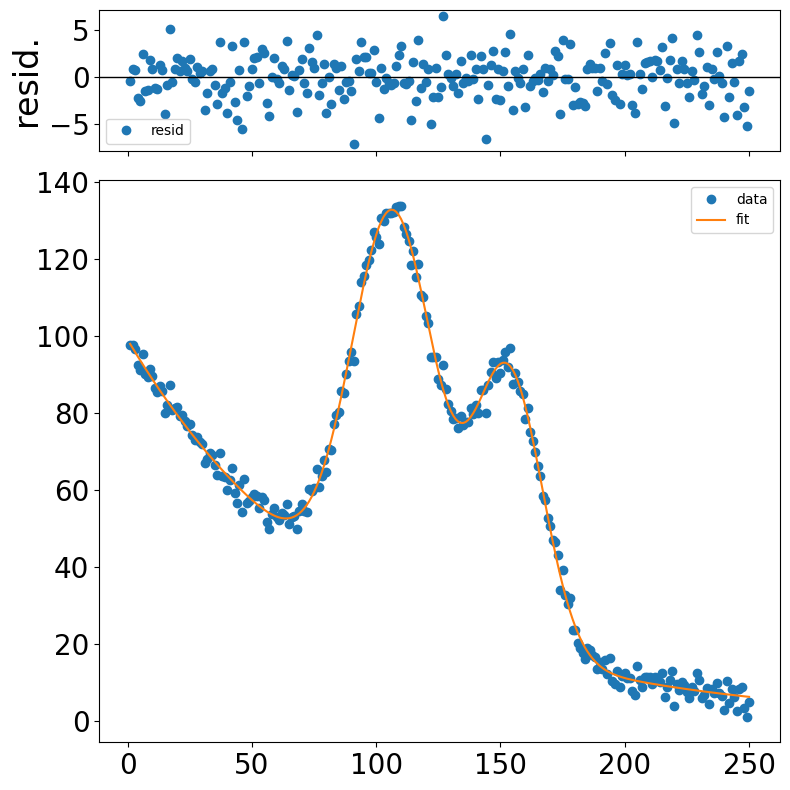

In [6]:
lg.report()
lg.plot()

In [7]:
def _data_label(i: int, is_multidataset: bool) -> str | None:
    if is_multidataset:
        return f"data {i+1}"
    return "data" if i == 0 else None

def _fit_label(i: int, is_multidataset: bool, same_fit_color: bool) -> str | None:
    if not is_multidataset:
        return "fit" if i == 0 else None
    if same_fit_color:
        return "fit" if i == 0 else None
    return f"fit {i+1}"

In [8]:
fd = lg.get_fitdata(numpoints=1024) # int or None
# fd.x_data
# fd.resid_fit

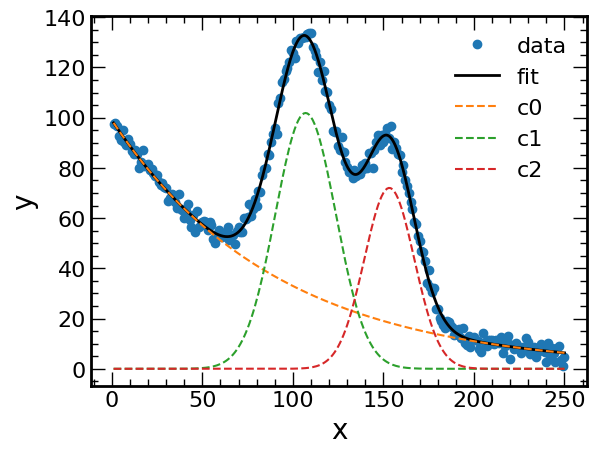

In [9]:
fig, ax = plt.subplots()


for i in range(fd.ny):
    # --- data ---
    ax.plot(
        fd.x_data,
        fd.y_data[:, i],
        'o',
        zorder=1,
        label=_data_label(i, fd.is_multidataset),
    )

    # --- fit ---
    ax.plot(
        fd.x_model,
        fd.y_fit[:, i],
        '-',
        lw=2,
        color='k',
        zorder=2,
        label=_fit_label(i, fd.is_multidataset, same_fit_color=True)
        # label="fit" if i == fd.ny-1 else None, # ONE legend entry only
    )

    # --- components ---
    comps = None
    comps_names = None
    if fd.is_multicomponent:
        comps = fd.components
        comps_names = fd.component_names
        if fd.is_multidataset:
            comp = comps[i]
        else:
            comp = comps
        for name in comps_names:
            d_dict = comp[name]
            ax.plot(fd.x_data,  d_dict['data'],  '--', zorder=3, label=name)
            # ax.plot(fd.x_model, d_dict['model'], '--', label=name)

# Styling
fontsize=16
ax.minorticks_on()
ax.set_xlabel('x', fontsize=fontsize+4)
ax.set_ylabel('y', fontsize=fontsize+4)
ax.tick_params(axis='x', labelsize=fontsize, labelcolor='k')  # Increase x-axis tick font size
ax.tick_params(axis='y', labelsize=fontsize, labelcolor='k')  # Increase y-axis tick font size
ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=fontsize, labelcolor="k")
ax.tick_params(axis="both", which="major", length=10, width=1.0)
ax.tick_params(axis="both", which="minor", length=5,  width=1.0)
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ax.legend()
ax.legend(
    prop={
        "size": fontsize,
        "family": "sans-serif",
        "weight": "normal",
    },
    frameon=False,
)
plt.show()

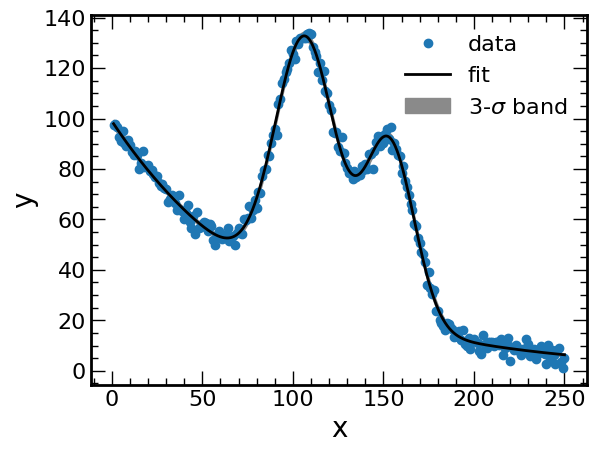

In [10]:
fig, ax = plt.subplots()

dely = lg.eval_uncertainty(
    x=fd.x_model,
    sigma=3
)

for i in range(fd.ny):

    # --- data ---
    ax.plot(
        fd.x_data,
        fd.y_data[:, i],
        'o',
        zorder=2,
        label=_data_label(i, fd.is_multidataset),
    )

    # --- fit ---
    ax.plot(
        fd.x_model,
        fd.y_fit[:, i],
        '-',
        lw=2,
        color='k',
        zorder=3,
        label=_fit_label(i, fd.is_multidataset, same_fit_color=True),
    )

    # --- uncertainty band ---
    ax.fill_between(
        fd.x_model,
        fd.y_fit[:, i] - dely[:, i],
        fd.y_fit[:, i] + dely[:, i],
        color="#8A8A8A",
        label=r'3-$\sigma$ band' if i == 0 else None,
    )

# Styling
fontsize=16
ax.minorticks_on()
ax.set_xlabel('x', fontsize=fontsize+4)
ax.set_ylabel('y', fontsize=fontsize+4)
ax.tick_params(axis='x', labelsize=fontsize, labelcolor='k')  # Increase x-axis tick font size
ax.tick_params(axis='y', labelsize=fontsize, labelcolor='k')  # Increase y-axis tick font size
ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=fontsize, labelcolor="k")
ax.tick_params(axis="both", which="major", length=10, width=1.0)
ax.tick_params(axis="both", which="minor", length=5,  width=1.0)
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ax.legend()
ax.legend(
    prop={
        "size": fontsize,
        "family": "sans-serif",
        "weight": "normal",
    },
    frameon=False,
)
plt.show()


In [11]:
PLOT_COMPONENTS = True
PLOT_TOTAL_UNCERTAINTY = True
PLOT_COMPONENT_UNCERTAINTY = True
SIGMA = 3


if PLOT_TOTAL_UNCERTAINTY or PLOT_COMPONENT_UNCERTAINTY:
    dely, dely_comps = lg.eval_uncertainty(
        x=fd.x_model,
        sigma=SIGMA,
        components=PLOT_COMPONENT_UNCERTAINTY,
    )
else:
    dely = dely_comps = None


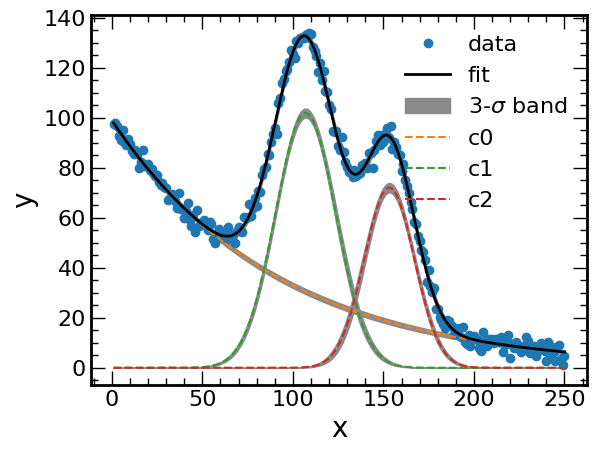

In [12]:
fig, ax = plt.subplots()

alpha_fill = 1
color_fill ="#8A8A8A",
for i in range(fd.ny):
    # Data
    ax.plot(
        fd.x_data,
        fd.y_data[:, i],
        "o",
        zorder=3,
        label=_data_label(i, fd.is_multidataset),
    )
    # Total fit
    ax.plot(
        fd.x_model,
        fd.y_fit[:, i],
        "-",
        lw=2,
        color="k",
        zorder=4,
        label=_fit_label(i, fd.is_multidataset, same_fit_color=True),
    )
    # Total uncertainty
    if PLOT_TOTAL_UNCERTAINTY:
        band_label = rf"{SIGMA}-$\sigma$ band" if i == 0 else None
        ax.fill_between(
            fd.x_model,
            fd.y_fit[:, i] - dely[:, i],
            fd.y_fit[:, i] + dely[:, i],
            zorder=2,
            color=color_fill,
            alpha=alpha_fill,
            label=band_label,
        )

    # Components
    if PLOT_COMPONENTS and fd.is_multicomponent:
        comps = fd.components[i] if fd.is_multidataset else fd.components

        for name in fd.component_names:
            comp = comps[name]

            # --- component curve ---
            line, = ax.plot(
                fd.x_model,
                comp["model"],
                "--",
                lw=1.5,
                zorder=3,
                label=name if i == 0 else None,
            )

            # --- component uncertainty ---
            if PLOT_COMPONENT_UNCERTAINTY:
                color = line.get_color()
                dy = dely_comps[name][:, i]

                ax.fill_between(
                    fd.x_model,
                    comp["model"] - dy,
                    comp["model"] + dy,
                    color=color_fill,
                    alpha=alpha_fill,
                    zorder=1,
                )

# Styling
fontsize=16
ax.minorticks_on()
ax.set_xlabel('x', fontsize=fontsize+4)
ax.set_ylabel('y', fontsize=fontsize+4)
ax.tick_params(axis='x', labelsize=fontsize, labelcolor='k')  # Increase x-axis tick font size
ax.tick_params(axis='y', labelsize=fontsize, labelcolor='k')  # Increase y-axis tick font size
ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=fontsize, labelcolor="k")
ax.tick_params(axis="both", which="major", length=10, width=1.0)
ax.tick_params(axis="both", which="minor", length=5,  width=1.0)
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ax.legend()
ax.legend(
    prop={
        "size": fontsize,
        "family": "sans-serif",
        "weight": "normal",
    },
    frameon=False,
)
plt.show()